**1. Introducción y Preparación de Datos**

**Fase 1:** Configuración del Entorno e Importación de Librerías

En esta etapa inicial, se preparan las herramientas necesarias para el análisis de datos y la construcción de modelos de aprendizaje automático. Se utilizan librerías fundamentales como Pandas y NumPy para la manipulación de datos, Matplotlib y Seaborn para la visualización, y Scikit-Learn junto con TensorFlow para implementar algoritmos de regresión y redes neuronales.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display
import sqlite3 as sq
print("Librerías cargadas con éxito.")

Librerías cargadas con éxito.


**2. Procesamiento y Limpieza (ETL)**

**Fase 2:** Extracción, Limpieza y Consolidación de Datos Históricos

El proyecto integra múltiples fuentes de datos meteorológicos y de contaminantes, incluyendo registros de PM2.5, NO2, lluvia, viento, humedad y temperatura desde el año 2010. Mediante una función personalizada, se limpian los encabezados, se estandarizan los formatos de fecha y se filtran los registros nulos para generar una "Tabla Maestra" unificada que sirve como base para todo el estudio posterior.

In [ ]:
#Función para procesar los registros meteorológicos y contaminantes desde el año 2010
def procesar_datos_quito(ruta, columna_estacion, nuevo_nombre):
  # Cargamos saltando la fila 1 de encabezados de unidades
  df = pd.read_excel(ruta, skiprows=[1])

  # renombramos la primera columna a Fecha
  df.rename(columns={df.columns[0] : 'Fecha'}, inplace = True)

  #Convertimos al formato de fecha DateTime para hacer un filtrado por los años
  df['Fecha'] = pd.to_datetime(df['Fecha'])

  #Filtramos solo desde el 1 de enero de 2010
  df = df[df['Fecha'] >= '2010-01-01']

  # Seleccionamos solo la fecha y la estación (Belisario)
  df = df[['Fecha', columna_estacion]].copy()
  df.columns = ['Fecha', nuevo_nombre]

  return df

Procesamos los 6 archivos de registros para trabajar con estos datos

***Nota: Por el tamaño de los registros suele demorar alrededor de 2 minutos el procesamiento completo***


In [ ]:
#procesamiento de archivos

try:
  df_pm25 = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/PM2.5.xlsx', 'BELISARIO', 'PM25')
  df_lluvia = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/LLU.xlsx', 'Belisario', 'Lluvia')
  df_viento = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/VEL.xlsx', 'Belisario', 'Viento')
  df_hum = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/HUM.xlsx', 'Belisario', 'Humedad')
  df_no2 = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/NO2.xlsx', 'BELISARIO', 'NO2')
  df_tmp = procesar_datos_quito('/content/drive/MyDrive/PROYECTO UIDE/TMP.xlsx', 'Belisario', 'Temperatura')
  print("Datos procesados y filtrados desde el años 2010")

except Exception as e:
  print(f"Error al cargar archivos: {e}. Asegurarse de haber subido los archivos a la carpeta Colab")

Datos procesados y filtrados desde el años 2010


Con la información de los registros creamos la "Tabla maestra" para el desarrollo del modelo

In [ ]:
try:
  #unir en un df_maestro
  df_maestro = df_pm25.merge(df_lluvia, on='Fecha')\
                        .merge(df_viento, on='Fecha')\
                        .merge(df_hum, on='Fecha')\
                        .merge(df_no2, on='Fecha')\
                        .merge(df_tmp, on='Fecha')
  #crear variables de tiempo
  df_maestro['Hora'] = df_maestro['Fecha'].dt.hour
  df_maestro['Dia_Semana'] = df_maestro['Fecha'].dt.day_of_week

  #limpieza y conversoin
  columnas_finales = ['PM25', 'Lluvia', 'Viento', 'Humedad', 'NO2', 'Temperatura']
  for col in columnas_finales:
    df_maestro[col] = pd.to_numeric(df_maestro[col], errors = 'coerce')

  #limpieza de nulos
  df_maestro = df_maestro.dropna().reset_index(drop = True)

  #convertimos todo
  print("Tabla maestra creada con éxito")
  print(f"Registros totales: {len(df_maestro)}")
  display(df_maestro.head(10))
except Exception as e:
  print(f"Error al integrar: {e}")
  print("Revisa que los archivos .xlsx esten en la ruta")


Tabla maestra creada con éxito
Registros totales: 77376


,Fecha,PM25,Lluvia,Viento,Humedad,NO2,Temperatura,Hora,Dia_Semana
0,2016-08-26 20:00:00,25.39,0.0,1.66,69.79,42.90,13.34,20,4
1,2016-08-26 21:00:00,13.46,0.0,1.06,71.58,38.50,12.61,21,4
2,2016-08-26 22:00:00,19.18,0.0,0.75,73.28,42.64,11.83,22,4
3,2016-08-26 23:00:00,18.40,0.0,0.70,78.91,36.95,11.68,23,4
4,2016-08-27 00:00:00,24.46,0.0,0.83,77.70,38.49,11.12,0,5
5,2016-08-27 01:00:00,22.06,0.0,0.95,77.24,39.45,11.07,1,5
6,2016-08-27 02:00:00,12.58,0.0,1.30,70.48,37.31,11.54,2,5
7,2016-08-27 03:00:00,10.15,0.0,1.36,69.25,29.17,11.20,3,5
8,2016-08-27 04:00:00,3.52,0.0,1.71,66.32,10.06,11.20,4,5
9,2016-08-27 05:00:00,6.40,0.0,2.42,61.90,15.53,11.66,5,5


**3. Almacenamiento Estructurado**

**Fase 3:** Persistencia de Datos en Entorno SQL

Para garantizar la integridad y el acceso eficiente a la información, el conjunto de datos procesado se almacena en una base de datos local utilizando SQLite. Se crea la tabla monitoreo_belisario, la cual permite realizar consultas estructuradas y facilita el manejo de los más de 77,000 registros totales generados durante la integración.

In [ ]:
#Almacenamiento en una base de datos SQlite
#agregamos un id
df_maestro.insert(0, 'id_medicion', range(1, 1+ len(df_maestro)))

#crear la conexion
try:
  conn = sq.connect('/content/drive/MyDrive/PROYECTO UIDE/calidad_aire_quito.db')
  cursor = conn.cursor()
  print("Conexión a la base de datos establecida con éxito")
  #guardamos el dataframe maestro en una tabla llamada monitoreo_belisario
  df_maestro.to_sql('monitoreo_belisario', conn, if_exists='replace', index=False)
  print("Tabla monitoreo_belisario creada con éxito")

  #verificamos que los datos esten correctamente almacenados
  query = "SELECT * FROM monitoreo_belisario LIMIT 10"
  verificacion = pd.read_sql_query(query, conn)
  print("Verificación de los datos almacenados en la tabla monitoreo_belisario:")
  display(verificacion)
  conn.close()
except Exception as e:
  print(f"Error al crear la base de datos: {e}")

Conexión a la base de datos establecida con éxito
Tabla monitoreo_belisario creada con éxito
Verificación de los datos almacenados en la tabla monitoreo_belisario:


,id_medicion,Fecha,PM25,Lluvia,Viento,Humedad,NO2,Temperatura,Hora,Dia_Semana
0,1,2016-08-26 20:00:00,25.39,0.0,1.66,69.79,42.90,13.34,20,4
1,2,2016-08-26 21:00:00,13.46,0.0,1.06,71.58,38.50,12.61,21,4
2,3,2016-08-26 22:00:00,19.18,0.0,0.75,73.28,42.64,11.83,22,4
3,4,2016-08-26 23:00:00,18.40,0.0,0.70,78.91,36.95,11.68,23,4
4,5,2016-08-27 00:00:00,24.46,0.0,0.83,77.70,38.49,11.12,0,5
5,6,2016-08-27 01:00:00,22.06,0.0,0.95,77.24,39.45,11.07,1,5
6,7,2016-08-27 02:00:00,12.58,0.0,1.30,70.48,37.31,11.54,2,5
7,8,2016-08-27 03:00:00,10.15,0.0,1.36,69.25,29.17,11.20,3,5
8,9,2016-08-27 04:00:00,3.52,0.0,1.71,66.32,10.06,11.20,4,5
9,10,2016-08-27 05:00:00,6.40,0.0,2.42,61.90,15.53,11.66,5,5


**4. Análisis Exploratorio (EDA)**

**Fase 4:** Análisis de Correlación y Dinámicas del Aire

Se emplea un mapa de calor para identificar cómo interactúan las variables climáticas con la concentración de partículas PM2.5. El análisis revela, por ejemplo, que el Dióxido de Nitrógeno (NO2) presenta la correlación más significativa con la contaminación por partículas en la estación Belisario, mientras que factores como la lluvia muestran una relación inversa mínima.

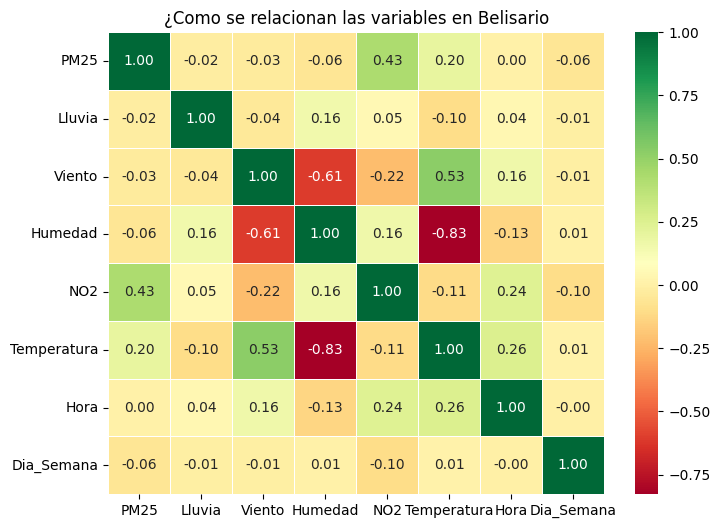

Valores de correlacion con respecto al PM25
PM25           1.000000
NO2            0.426866
Temperatura    0.195277
Hora           0.003972
Lluvia        -0.016852
Viento        -0.028247
Dia_Semana    -0.057221
Humedad       -0.057839
Name: PM25, dtype: float64


In [ ]:
#ANALISIS DE CORRELACION
#calculamos la matriz de correlacion

columnas_interes = ['PM25', 'Lluvia' ,'Viento', 'Humedad', 'NO2', 'Temperatura', 'Hora', 'Dia_Semana']
matriz_corr = df_maestro[columnas_interes].corr()

#creamos el grafico de mapa de calor
plt.figure(figsize = (8, 6))
sns.heatmap(matriz_corr, annot = True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title("¿Cómo se relacionan las variables en Belisario?")
plt.show()

#mostramos los valores exactos
print("Valores de correlacion con respecto al PM25")
print(matriz_corr['PM25'].sort_values(ascending = False))


**5. Modelado Predictivo**

**Fase 5:** Desarrollo y Comparación de Modelos de Machine Learning

Se implementan tres enfoques distintos para predecir los niveles de PM2.5: Regresión Lineal, Random Forest y Redes Neuronales Profundas. El modelo de

Random Forest y la Red Neuronal logran capturar patrones no lineales más complejos, alcanzando un coeficiente de determinación ($R^2$) de aproximadamente 0.35 a 0.36, superando el ajuste básico de la regresión lineal.

**ENTRENAMIENTO DEL MODELO (LINEAR REGRESSION)**



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
#Entrenamiento
X = df_maestro[['Viento', 'Lluvia', 'Humedad', 'NO2', 'Temperatura','Hora', 'Dia_Semana']]
y = df_maestro['PM25']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#crear y entrenar el modelo lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

#prediciones
y_pred_lr = modelo_lr.predict(X_test)

#metricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Resultados de Regresión Lineal")
print(f"Error medio absoluto (MAE): {mae_lr:.2f}")
print(f"Coeficiente de determinación (R^2): {r2_lr:.2f}")

Resultados de Regresión Lineal
Error medio absoluto (MAE): 6.20
Coeficiente de determinación (R^2): 0.29


Gráfico de línea de ajuste - Linear Regression


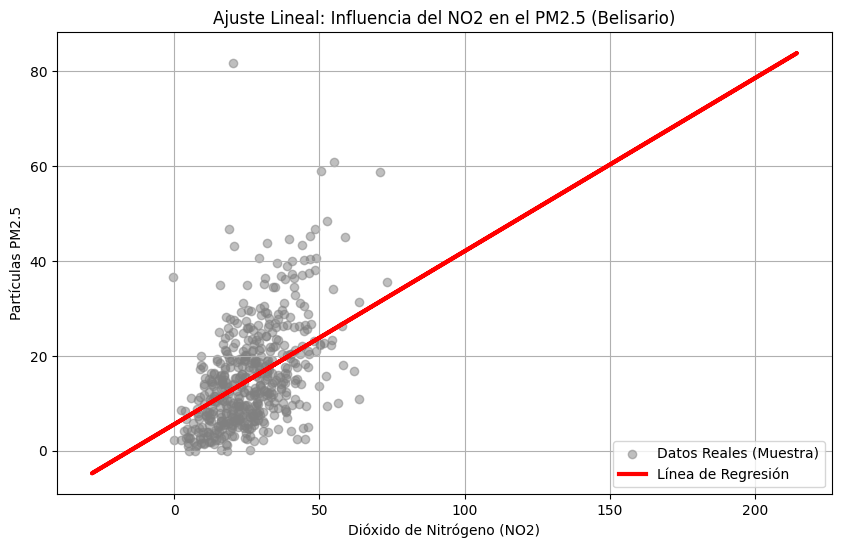

In [ ]:
plt.figure(figsize=(10,6))

#dibujar una muestra de los puntos reales
plt.scatter(X_test['NO2'].head(500), y_test.head(500), color= 'gray', alpha=0.5, label="Datos Reales (Muestra)")

#dibujar linea de tendencia
m, b = np.polyfit(X_test['NO2'], y_pred_lr, 1)
plt.plot(X_test['NO2'], m*X_test['NO2'] + b, color='red', linewidth=3, label='Línea de Regresión')

plt.title("Ajuste Lineal: Influencia del NO2 en el PM2.5 (Belisario)")
plt.xlabel("Dióxido de Nitrógeno (NO2)")
plt.ylabel("Partículas PM2.5")
plt.legend()
plt.grid(True)
plt.show()

**ENTRENAMIENTO DEL MODELO (RANDOM FOREST)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


#crear el modelo con 100 árboles de desicion
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

#entrenaimento con el 80% de mis datos
print("Entrenando el modelo con los registros... por favor espera")
modelo_rf.fit(X_train, y_train)
#prediciones
predicciones = modelo_rf.predict(X_test)

#metricas
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)
print("Resultados de Random Forest")
print(f"Error medio absoluto (MAE): {mae:.2f}")
print(f"Coeficiente de determinación (R^2): {r2:.2f}")

Entrenando el modelo con los registros... por favor espera
Resultados de Random Forest
Error medio absoluto (MAE): 5.76
Coeficiente de determinación (R^2): 0.35


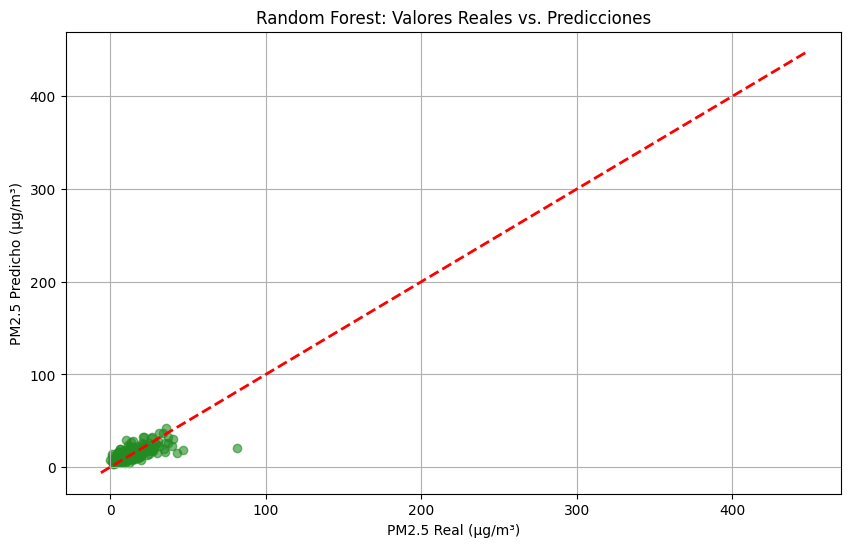

In [ ]:
# 5. Gráfico de Dispersión: Real vs Predicho
plt.figure(figsize=(10, 6))
plt.scatter(y_test.head(200), predicciones[:200], color='forestgreen', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Valores Reales vs. Predicciones')
plt.xlabel('PM2.5 Real (µg/m³)')
plt.ylabel('PM2.5 Predicho (µg/m³)')
plt.grid(True)
plt.show()

**ENTRENAMIENTO DEL MODELO (NEURAL NETWORK)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import layers as Layer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Escalamiento de redes neuronales
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#definir early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)
#Arquitectura de la red
modelo_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    Dense(1)
])

#compilacion y entrenamiento
modelo_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("Entrenando la Red Neuronal en tensorFlow...")
history = modelo_nn.fit(X_train_scaled, y_train,
                        epochs=60,
                        batch_size=32,
                        validation_split=0.2,
                        callbacks=[early_stopping],
                        verbose=1)

#preddciones y metricas
y_pred_nn = modelo_nn.predict(X_test_scaled).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
print(f"\n--- RESULTADOS RED NEURONAL ---")
print(f"MAE: {mae_nn:.2f}")
print(f"R2: {r2_nn:.2f}")

Entrenando la Red Neuronal en tensorFlow...
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1548/1548 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 121.3972 - mae: 7.9911 - val_loss: 110.1886 - val_mae: 5.8284
Epoch 2/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 74.3517 - mae: 6.1090 - val_loss: 109.5927 - val_mae: 5.8027
Epoch 3/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 72.8550 - mae: 6.0303 - val_loss: 109.1677 - val_mae: 5.8303
Epoch 4/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 72.0643 - mae: 6.0135 - val_loss: 108.7007 - val_mae: 5.7789
Epoch 5/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 71.4076 - mae: 5.9629 - val_loss: 109.1191 - val_mae: 5.8480
Epoch 6/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 71.2747 - mae: 5.9637 - val_loss: 108.4828 - val_mae: 5.7711
Epoch 7/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 70.9744 - mae: 5.9448 - val_loss: 108.0646 - val_mae: 5.7119
Epoch 8/60
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 70.9169 - mae: 5.9333 - val_loss: 108.5815 - val_mae: 5.7822
Epoch 9/60
1548/1548 ━━━━

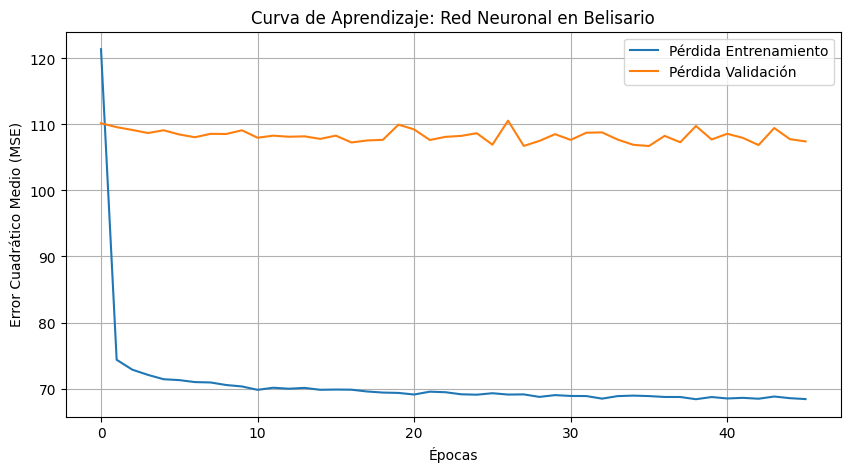

In [ ]:
# 5. VISUALIZACIÓN DEL APRENDIZAJE
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Curva de Aprendizaje: Red Neuronal en Belisario')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Curva red neuronal

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


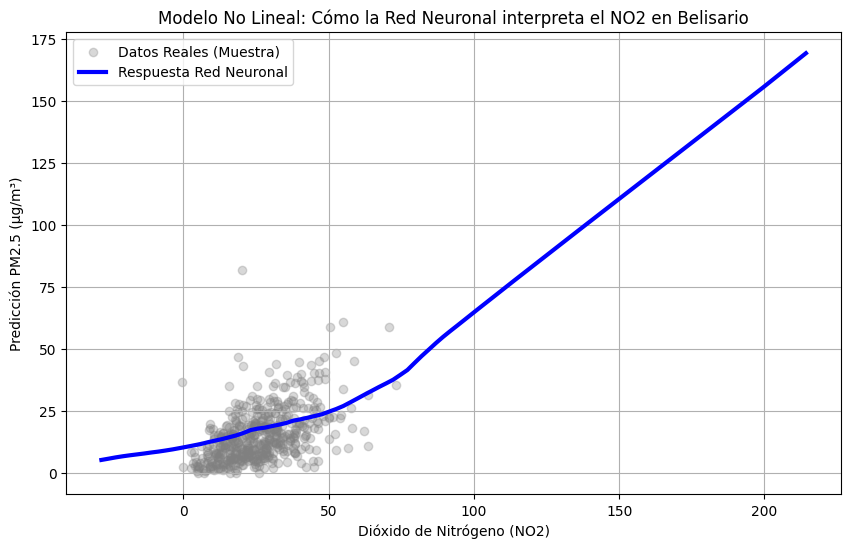

In [ ]:
# 1. Creamos un rango de valores de NO2 (desde el mínimo al máximo detectado)
no2_min, no2_max = X_test['NO2'].min(), X_test['NO2'].max()
no2_range = np.linspace(no2_min, no2_max, 100)

# 2. Creamos datos sintéticos: fijamos el clima en valores promedio
# para aislar solo el efecto del NO2 en la red neuronal
X_curva = pd.DataFrame({
    'Viento': [X_test['Viento'].mean()] * 100,
    'Lluvia': [X_test['Lluvia'].mean()] * 100,
    'Humedad': [X_test['Humedad'].mean()] * 100,
    'NO2': no2_range,
    'Temperatura': [X_test['Temperatura'].mean()] * 100,
    'Hora': [12] * 100, # Suponiendo mediodía
    'Dia_Semana': [2] * 100 # Suponiendo un miércoles (día laboral)
})

# 3. Escalamos los datos (mismo scaler que usamos para entrenar)
X_curva_scaled = scaler_X.transform(X_curva)

# 4. Predecimos con la Red Neuronal de TensorFlow
y_pred_curva_nn = modelo_nn.predict(X_curva_scaled).flatten()

# 5. GRAFICAMOS
plt.figure(figsize=(10, 6))

# Dibujamos una muestra de los datos reales de fondo
plt.scatter(X_test['NO2'].head(500), y_test.head(500), color='gray', alpha=0.3, label='Datos Reales (Muestra)')

# Dibujamos la curva de la Red Neuronal
plt.plot(no2_range, y_pred_curva_nn, color='blue', linewidth=3, label='Respuesta Red Neuronal')

plt.title('Modelo No Lineal: Cómo la Red Neuronal interpreta el NO2 en Belisario')
plt.xlabel('Dióxido de Nitrógeno (NO2)')
plt.ylabel('Predicción PM2.5 (µg/m³)')
plt.legend()
plt.grid(True)
plt.show()

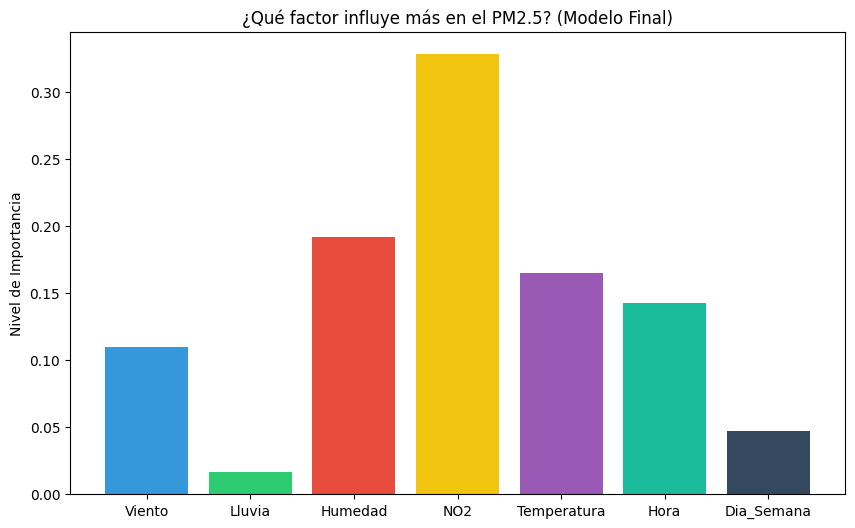

Viento: 10.96%
Lluvia: 1.65%
Humedad: 19.19%
NO2: 32.79%
Temperatura: 16.47%
Hora: 14.21%
Dia_Semana: 4.73%


In [ ]:
# Graficar la importancia de las 7 variables
importancias = modelo_rf.feature_importances_
nombres_columnas = X.columns

plt.figure(figsize=(10, 6))
plt.bar(nombres_columnas, importancias, color=['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', '#1abc9c', '#34495e'])
plt.title('¿Qué factor influye más en el PM2.5? (Modelo Final)')
plt.ylabel('Nivel de Importancia')
plt.show()

for i, v in enumerate(importancias):
    print(f"{nombres_columnas[i]}: {v*100:.2f}%")

484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


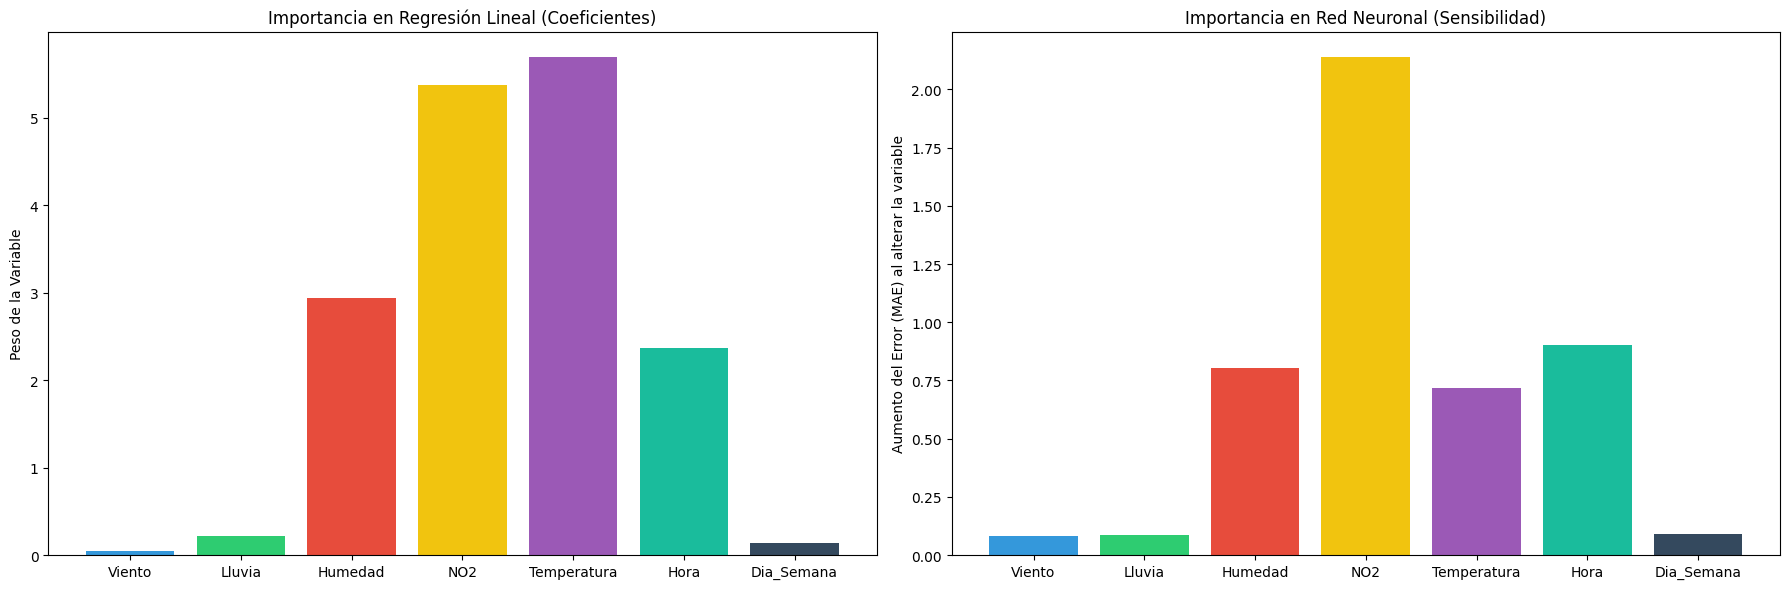

In [ ]:
# 1. IMPORTANCIA EN REGRESIÓN LINEAL
# Entrenamos con datos normalizados para que los coeficientes sean comparables
modelo_lr_norm = LinearRegression()
modelo_lr_norm.fit(X_train_scaled, y_train)
importancia_lr = np.abs(modelo_lr_norm.coef_) # Usamos valor absoluto

# 2. IMPORTANCIA EN RED NEURONAL (Técnica de Permutación)
def calcular_importancia_nn(model, X_val, y_val, columns):
    base_pred = model.predict(X_val).flatten()
    base_mae = mean_absolute_error(y_val, base_pred)
    imp = []
    for i in range(len(columns)):
        X_perm = X_val.copy()
        np.random.shuffle(X_perm[:, i]) # Mezclamos la columna para "romper" su info
        perm_mae = mean_absolute_error(y_val, model.predict(X_perm).flatten())
        imp.append(perm_mae - base_mae) # ¿Cuánto subió el error?
    return np.array(imp)

importancia_nn = calcular_importancia_nn(modelo_nn, X_test_scaled, y_test, X.columns)

# 3. GRÁFICOS COMPARATIVOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', '#1abc9c', '#34495e']

# Gráfico Regresión Lineal
ax1.bar(X.columns, importancia_lr, color=colores)
ax1.set_title('Importancia en Regresión Lineal (Coeficientes)')
ax1.set_ylabel('Peso de la Variable')

# Gráfico Red Neuronal
ax2.bar(X.columns, importancia_nn, color=colores)
ax2.set_title('Importancia en Red Neuronal (Sensibilidad)')
ax2.set_ylabel('Aumento del Error (MAE) al alterar la variable')

plt.tight_layout()
plt.show()